# 15:16 High-Capacty Convolutional Encoder for Binary Images!
## Embedding rate = 87.5%

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
import cv2
import random
import time
from skimage.util import random_noise

# Standard number of bits, n = 8 considered
K = 2**8

# data embedding key
DATA_EMBEDDING_KEY = 2718284590 

In [2]:
# function which takes a grayscale image as 
# input and returns the histogram of that image.
def Histogram(image):
    # initialize all the values in dictionary to 0
    histogram = {val:0 for val in range(K)}
    
    # go through the pixels in the image to 
    # compute histogram values
    for row in range(image.shape[0]):
        for col in range(image.shape[1]):
            if int(image[row][col]) in histogram:
                histogram[int(image[row][col])] += 1

    return histogram

In [3]:
# function which takes grayscale image, threshold as 
# inputs and returns the value of intra class variance
# (sigma_w^2(th)), also called as within class variance.
def WithinClassVariance(histogram, threshold):
    
    # class probabilites
    w0 = sum([histogram[val] for val in range(threshold + 1)]) / sum(histogram.values())
    w1 = 1 - w0

    # if probability of any class is 0, then mean, 
    # variance of classes are not defined. Since, we need
    # to minimize intra-class variance, assign it to infinity
    if w0 == 0 or w0 == 1:
        return np.inf

    # class means    
    u0 = sum([val*histogram[val] for val in range(threshold + 1)]) / (w0 * sum(histogram.values()))
    u1 = sum([val*histogram[val] for val in range(threshold + 1, K)]) / (w1 * sum(histogram.values()))
    
    # class variances
    v0 = sum([((val - u0)**2)*histogram[val] for val in range(threshold + 1)]) / (w0 * sum(histogram.values()))
    v1 = sum([((val - u1)**2)*histogram[val] for val in range(threshold + 1, K)]) / (w1 * sum(histogram.values()))    

    intraClassVar = w0*v0 + w1*v1
    return intraClassVar

In [4]:
# computes the optimum value of threshold based 
# on minimizing intra-class(within class) variance.
def OtsuMinimizeWithinClassVariance(image):
    MinIntraClassVar = None

    # get the histogram
    histogram = Histogram(image)

    # go through all the thresholds from 0 to 255 to
    # minimize intra-class variance
    for threshold in range(K):
        intraClassVar = WithinClassVariance(histogram, threshold)
        if MinIntraClassVar == None:
            (MinIntraClassVar, BestOtsuThreshold) = (intraClassVar, threshold)
        if intraClassVar < MinIntraClassVar:
            (MinIntraClassVar, BestOtsuThreshold) = (intraClassVar, threshold)

    return BestOtsuThreshold

In [5]:
# function which takes the secret text and embedding key as inputs 
# and returns encrypted secret data as output (in bits) by XOR-ing
# prng_sequence and secret text.
def EncryptSecretData(data_to_encrypt, key_seed, BI):
    byte_sequence = data_to_encrypt.encode('ascii')
    binary_strings = [format(byte, '08b') for byte in byte_sequence]
    all_bits_str = "".join(binary_strings)
    binary_data = np.array([int(bit) for bit in all_bits_str], dtype=np.uint8)

    # EMBEDDING RATE HERE
    embedding_rate = 14

    
    pixels = BI.shape[0]*BI.shape[1]
    #no_of_encryptable_bits = int(pixels * embedding_rate) - (int(pixels * embedding_rate) % 8)
    no_of_encryptable_bits = int(pixels * embedding_rate)
    
    # process the binary secret data to match no of encryptable bits
    if len(binary_data) > no_of_encryptable_bits:
        binary_data = binary_data[0:no_of_encryptable_bits]
    elif len(binary_data) < no_of_encryptable_bits:
        zero_padding = np.zeros((no_of_encryptable_bits - len(binary_data)), dtype=np.uint8)
        binary_data = np.concatenate((binary_data, zero_padding))

    
    data_len = binary_data.size
    
    # based on embedding key
    random.seed(key_seed)
    prng_sequence = np.array([random.randint(0, 1) for _ in range(data_len)], dtype=int)
    secret_data = np.bitwise_xor(binary_data, prng_sequence)

    return secret_data

In [6]:
# function which takes grayscale image and threshold as 
# inputs and returns a binarized image based on threshold.
def BinarizedImage(image):
    if len(image.shape) > 2:
        grayscale_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        grayscale_image = image
    threshold = OtsuMinimizeWithinClassVariance(grayscale_image)
    
    return (grayscale_image > threshold).astype(np.uint8)

In [7]:
# function which takes secret data in bits and key seed as inputs, 
# decrypts the secret data and returns the secret text.
def DecryptEmbeddedData(secret_data, key_seed):

    # make sure the length is divisible by 8
    if len(secret_data) % 8 != 0:
        secret_data = secret_data[0: len(secret_data) - (len(secret_data) % 8)]
    
    # re-create the exact same prng_sequence
    random.seed(key_seed)
    prng_sequence = np.array([random.randint(0, 1) for _ in range(secret_data.size)], dtype=int)

    # recover by again performing XOR
    recovered_data = np.bitwise_xor(secret_data, prng_sequence)

    byte_vectors = recovered_data.reshape(-1, 8)
    weights = np.array([128, 64, 32, 16, 8, 4, 2, 1], dtype=np.uint8)
    decimal_values = byte_vectors.dot(weights)
    byte_string = decimal_values.astype(np.uint8).tobytes()
    ascii_string = byte_string.decode('ascii')
    
    return ascii_string

In [8]:
def hamming_distance(str1, str2):
    if len(str1) != len(str2): return
    distance = 0
    for char1, char2 in zip(str1, str2):
        if char1 == '?' or char2 == '?': continue
        if char1 != char2:
            distance += 1
    return distance

In [9]:
def ComputePermutations(num):
    outputs = []
    for i in range(2**num):
        val = f"{i:0{num}b}"
        outputs.append(val)

    return outputs

In [10]:
def ConvolutionalEncoder(polynomial, input_bits, puncture_pattern):
    L = len(str(polynomial[0])) - 1
    for p in polynomial[1:]:
        if len(str(p)) - 1 != L:
            print("Error!!")

    # number of inputs and outputs!
    inputs = 1
    outputs = len(polynomial)
    
    
    # No. of states = 2^2 = 4
    number_of_states = 2**L
    
    state_transitions = dict()
    
    # idea is that the input will be of the form
    # (present state, input), 
    # output is (next state, output)!
    states = ComputePermutations(L)
    for state in states:    
        all_inputs = ComputePermutations(inputs)
        for ip in all_inputs:
            new = ip + state 
            newState = new[:-1]
            finalOutput = ""
            for op in range(outputs):
                output_polynomial = str(polynomial[op])
                if len(output_polynomial) != L + 1: break
                
                output = int(ip) * int(output_polynomial[0])
                for itr in range(1, len(output_polynomial)):
                    output = output ^ int(output_polynomial[itr])*int(state[itr-1])
                
                finalOutput += str(output)
    
            state_transitions[(state, ip)] = (newState, finalOutput)
    
    
    initial_state = f"{0:0{L}b}"
    input_string = str(input_bits[0])
    
    output_bits = []
    present_state = initial_state
    
    for bit in input_bits:
        (new_state, output) = state_transitions[(present_state, str(bit))]
        for itr in range(len(output)):
            output_bits.append(int(output[itr]))
        present_state = new_state


    # puncturing here only
    # puncture_pattern = [1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0]

    index = 0
    length = len(puncture_pattern)
    punctured_output = []
    for bit in output_bits:
        if puncture_pattern[index] == 1:
            punctured_output.append(bit)
        index = (index + 1) % length

    return (punctured_output, state_transitions)

In [11]:
def decodeViterbi(trellis_path, reverseMap):
    L = 2
    least_metric=np.inf
    for path, metric in trellis_path.items():
        if metric < least_metric:
            FinalPath = path
            least_metric = metric

    output_states = [FinalPath[i:i+L] for i in range(0, len(FinalPath), L)]

    prev_state = output_states[0]
    FinalDecodedOutput = []
    for current_state in output_states[1:]:
        transition = prev_state + current_state
        FinalDecodedOutput.append(int(reverseMap[transition]))
        prev_state = current_state

    return (FinalDecodedOutput, FinalPath[-L:])

In [12]:
def ViterbiDecoder(state_transitions, punctured_output, puncture_pattern, depth):

    actual_output = []
    index = 0
    L = 2
    inputs = 1
    length = len(puncture_pattern)

    for bit in punctured_output:
    
        if puncture_pattern[index] == 0:
            actual_output.append('?')
            index = (index + 1) % length

        if puncture_pattern[index] == 0:
            actual_output.append('?')
            index = (index + 1) % length
            
        if puncture_pattern[index] == 1:
            actual_output.append(bit)
            index = (index + 1) % length
        
    if len(actual_output) % L != 0:
        for i in range(len(actual_output)%L):
            actual_output.append('?')
    
    
    concatenated_bits = ["".join(map(str, actual_output[i:i+L])) for i in range(0, len(actual_output), L)]
    
    encoded_bits = concatenated_bits
    initial_state = f"{0:0{L}b}"
    trellis_path = dict({initial_state:0})
    
    reverseMap = dict()
    for key, val in state_transitions.items():
        (presentState, ip) = key
        (nextState, op) = val
        reverseMap[presentState + nextState] = ip
    
    all_inputs = ComputePermutations(inputs)
    finalOutput = []
    
    for stage in range(len(encoded_bits)):
        new_trellis = {}
        for path, old_metric in trellis_path.items():       
            for ip in all_inputs:
                (newState, output) = state_transitions[(path[-L:], ip)]
                #print(output, encoded_bits[stage],  hamming_distance(encoded_bits[stage], output) )
                updated_metric = old_metric + hamming_distance(encoded_bits[stage], output)
                updated_path = path + newState
                new_trellis[updated_path] = updated_metric
        
        minimum_metric = dict()
    
        for path, metric in new_trellis.items():
            state = path[-L:]
            if state in minimum_metric:
                (storedPath, storedMetric) = minimum_metric[state]
                if metric < storedMetric:
                    minimum_metric[state] = (path, metric) 
            else: 
                minimum_metric[state] = (path, metric)
        
        updated_trellis = {}
        for key, val in minimum_metric.items():
            (path, metric) = val
            updated_trellis[path] = metric
        trellis_path = updated_trellis
        
        if stage != 0 and stage % depth == 0:
            (Output2, LastState) = decodeViterbi(trellis_path, reverseMap)
            finalOutput.extend(Output2)
            trellis_path = {LastState:0}
    
    
    (Output3, LastState) = decodeViterbi(trellis_path, reverseMap)
    finalOutput.extend(Output3)
    
    return finalOutput

## ENCODING

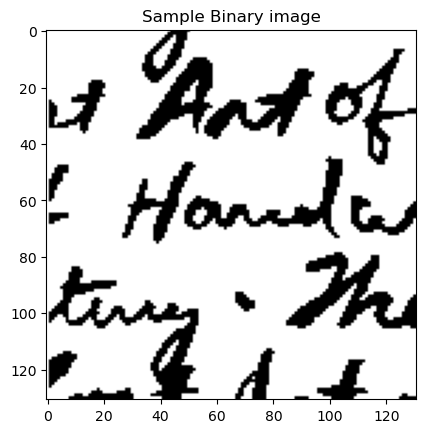

In [13]:
image = imread('Samples/Handwriting.png')
BI = BinarizedImage(image)

# dimension of chosen image
X, Y = BI.shape

plt.imshow(BI, cmap='gray')
plt.title("Sample Binary image")
plt.show()

In [14]:
# open the secret message and encrypt it
with open('Samples/SECRET_MESSAGE.TXT', 'r') as file:
    secret_message = file.read()

secret_data_in_bits = EncryptSecretData(secret_message, DATA_EMBEDDING_KEY, BI)
print("Length of secret message (in bits): " + str(len(secret_message)*8))
print("Adjusted length of secret message (in bits): " + str(len(secret_data_in_bits)))

Length of secret message (in bits): 1637088
Adjusted length of secret message (in bits): 240254


In [15]:
VectorizedBI = BI.reshape(BI.shape[0] * BI.shape[1])
SCALING_FACTOR = 4
totLen = int(15)

# Create an empty array of the correct size
interlaced_array = np.empty(VectorizedBI.size + secret_data_in_bits.size, dtype=VectorizedBI.dtype)

# Assign elements using slicing
interlaced_array[0::totLen] = VectorizedBI  # Assign arr1 to even indices

# for j in range(0, 15):
#    interlaced_array[(int(j)+1)::totLen] = secret_data_in_bits[int(j)::(totLen - 1)]

interlaced_array[1::15]  = secret_data_in_bits[0::14]
interlaced_array[2::15]  = secret_data_in_bits[1::14]
interlaced_array[3::15]  = secret_data_in_bits[2::14]
interlaced_array[4::15]  = secret_data_in_bits[3::14]
interlaced_array[5::15]  = secret_data_in_bits[4::14]
interlaced_array[6::15]  = secret_data_in_bits[5::14]
interlaced_array[7::15]  = secret_data_in_bits[6::14]
interlaced_array[8::15]  = secret_data_in_bits[7::14]
interlaced_array[9::15]  = secret_data_in_bits[8::14]
interlaced_array[10::15] = secret_data_in_bits[9::14]
interlaced_array[11::15] = secret_data_in_bits[10::14]
interlaced_array[12::15] = secret_data_in_bits[11::14]
interlaced_array[13::15] = secret_data_in_bits[12::14]
interlaced_array[14::15] = secret_data_in_bits[13::14]


polynomial = [111, 101]
puncture_pattern = [1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0]


start = time.time()

(Encoded_bits, state_transitions) = ConvolutionalEncoder(polynomial, interlaced_array, puncture_pattern)

end = time.time()

print("ENCODING TIME:", end - start)
print("Length of Encoded Bits:", len(Encoded_bits))

ENCODING TIME: 0.2786102294921875
Length of Encoded Bits: 274576


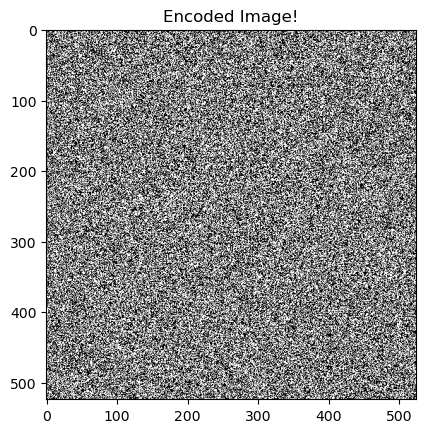

Size of Encoded image (524, 524)


In [19]:
encoded_image = np.empty((BI.shape[0]*SCALING_FACTOR, BI.shape[1]*SCALING_FACTOR), dtype=np.uint8)

itr = 0
for row in range(BI.shape[0]):
    for col in range(BI.shape[1]):
        encoded_image[SCALING_FACTOR*row][SCALING_FACTOR*col]     = Encoded_bits[itr]
        encoded_image[SCALING_FACTOR*row][SCALING_FACTOR*col + 1] = Encoded_bits[itr + 1]
        encoded_image[SCALING_FACTOR*row][SCALING_FACTOR*col + 2] = Encoded_bits[itr + 2]
        encoded_image[SCALING_FACTOR*row][SCALING_FACTOR*col + 3] = Encoded_bits[itr + 3]

        
        encoded_image[SCALING_FACTOR*row + 1][SCALING_FACTOR*col]     = Encoded_bits[itr + 4]
        encoded_image[SCALING_FACTOR*row + 1][SCALING_FACTOR*col + 1] = Encoded_bits[itr + 5]
        encoded_image[SCALING_FACTOR*row + 1][SCALING_FACTOR*col + 2] = Encoded_bits[itr + 6]
        encoded_image[SCALING_FACTOR*row + 1][SCALING_FACTOR*col + 3] = Encoded_bits[itr + 7]

        encoded_image[SCALING_FACTOR*row + 2][SCALING_FACTOR*col]     = Encoded_bits[itr + 8]
        encoded_image[SCALING_FACTOR*row + 2][SCALING_FACTOR*col + 1] = Encoded_bits[itr + 9]
        encoded_image[SCALING_FACTOR*row + 2][SCALING_FACTOR*col + 2] = Encoded_bits[itr + 10]
        encoded_image[SCALING_FACTOR*row + 2][SCALING_FACTOR*col + 3] = Encoded_bits[itr + 11]


        encoded_image[SCALING_FACTOR*row + 3][SCALING_FACTOR*col]     = Encoded_bits[itr + 12]
        encoded_image[SCALING_FACTOR*row + 3][SCALING_FACTOR*col + 1] = Encoded_bits[itr + 13]
        encoded_image[SCALING_FACTOR*row + 3][SCALING_FACTOR*col + 2] = Encoded_bits[itr + 14]
        encoded_image[SCALING_FACTOR*row + 3][SCALING_FACTOR*col + 3] = Encoded_bits[itr + 15]
        
        itr += SCALING_FACTOR*SCALING_FACTOR

plt.imshow(encoded_image, cmap='gray')
plt.title("Encoded Image!")
plt.show()
print("Size of Encoded image", encoded_image.shape)

# DECODING

In [20]:
rx_image = encoded_image
rx_encoded_bits = np.empty((rx_image.size,), dtype=np.uint8)

actual_rows = rx_image.shape[0] // SCALING_FACTOR 
actual_cols = rx_image.shape[1] // SCALING_FACTOR

itr = 0
for i in range(actual_rows):
    for j in range(actual_cols):
        # 3x3 block and serialize
        rx_encoded_bits[itr : itr + SCALING_FACTOR * SCALING_FACTOR] = np.reshape(rx_image[i*SCALING_FACTOR: i*SCALING_FACTOR + SCALING_FACTOR, j*SCALING_FACTOR: j* SCALING_FACTOR + SCALING_FACTOR], (SCALING_FACTOR*SCALING_FACTOR,))
        itr += SCALING_FACTOR* SCALING_FACTOR


start = time.time()

decoded_bits = ViterbiDecoder(state_transitions, rx_encoded_bits, puncture_pattern, 1)

end = time.time()
print("DECODING TIME:", end - start)


DECODING TIME: 1.5483169555664062


In [21]:
decoded_image = []
secret_data = []
for itr in range(0, len(decoded_bits), SCALING_FACTOR*SCALING_FACTOR - 1):
    decoded_image.append(decoded_bits[itr])
    secret_data.extend(decoded_bits[itr + 1: itr + SCALING_FACTOR*SCALING_FACTOR - 1])


In [22]:
secret_data = DecryptEmbeddedData(np.array(secret_data), DATA_EMBEDDING_KEY)

# NOT Printing entire message (which is tooo lengthy)
print("Decoded message:\n", secret_data[0:2036])

Decoded message:
 CHAPTER WISE SUMMARY OF BHAGAVAD-GITA AS IT IS

Chapter 1: Observing the Armies on the Battlefield of Kurukshetra
Two armies, those of the Pandavas and the Kauravas, face each other on the Battlefield of Kurukshetra. Many signs indicate victory for the Pandavas. Dhrtarashtra, the Pandavas' uncle and the Kauravas' father, doubts the possibility of his sons' victory and asks Sanjaya, his secretary, to describe the scene on the battlefield.

Arjuna, one of five Pandava brothers, undergoes a crisis just before the fight. He is overwhelmed by compassion for his family members and teachers, whom he is supposed to kill. After submitting before Krishna many noble and moral reasons why he wishes not to fight, Arjuna casts aside his weapons, overwhelmed with grief. Arjuna's reluctance to fight indicates his kind heart; such a person is fit to receive transcendental knowledge.

Chapter 2: Contents of the Gita Summarized
Krishna does not sympathize with Arjuna's arguments. Rather

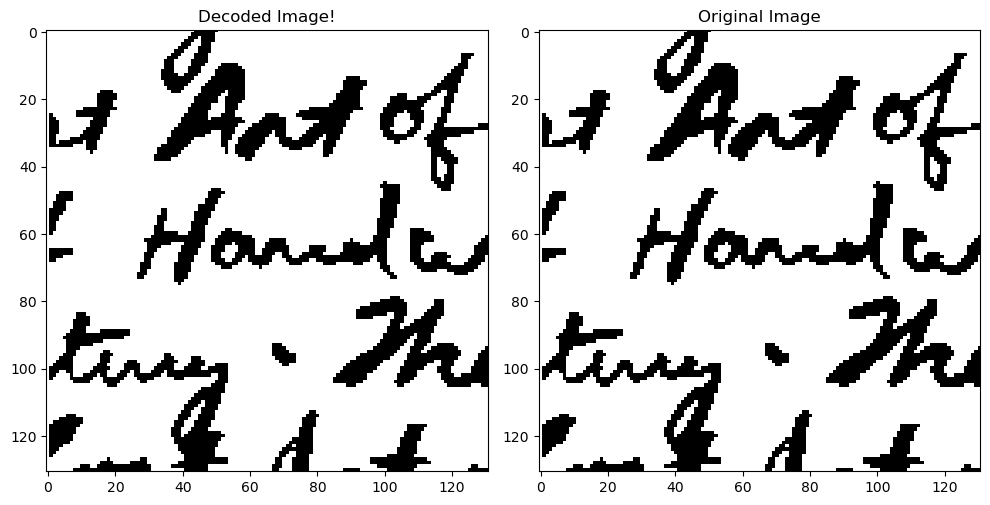

In [23]:
finalImage = np.array(decoded_image).reshape((X, Y))
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Display the first image
axes[0].imshow(finalImage, cmap='gray')
axes[0].set_title("Decoded Image!")

# Display the second image
axes[1].imshow(BI, cmap='gray')
axes[1].set_title("Original Image")

# Show the window or notebook plot
plt.tight_layout()
plt.show()
